# Data Visualization
*Bad programmers worry about the code. Good programers worry about data structures and their relationships -Linus Torvalds*

Skipping ahead in the book, past the python fundamentals. Chapters 3-7 are very important for anyone that is new to the python programming language. I am skipping ahead given my 8 years of experience with the language. In this chapter, we will still cover some basics, but it will give some great examples of using the matplotlib and plotly libraries for data visualization tasks. Visualizing data and analyzing plots is the heart of data science.

In [1]:
%%html
<style>
  table {margin-left: 0 !important;}
</style>

In [2]:
import matplotlib as mpl
mpl.__version__

'3.5.1'

In [3]:
import matplotlib.pyplot as plt
plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

## One-Dimensional Data Sets
The core plotting function is plt.plot(), which takes 2 parameters: x and y values. As you can imagine, the x values are plotted along the x-axis of a graph and the y values are plotted along the y-axis. As an example of how this works, lets work through an example using numpy's random number generator.

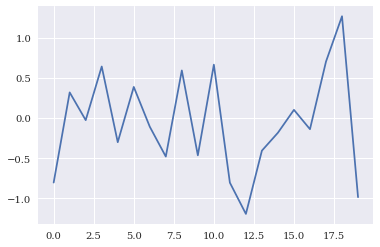

In [4]:
import numpy as np
np.random.seed(1000)
y = np.random.standard_normal(20)
x = np.arange(len(y))
plt.plot(x, y);

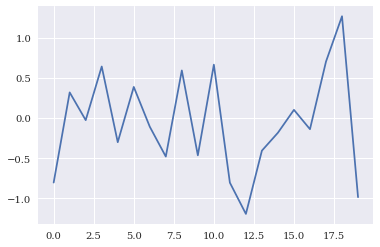

In [5]:
# if only providing the y values, plt.plot() will take the index values as the respective x values
plt.plot(y)

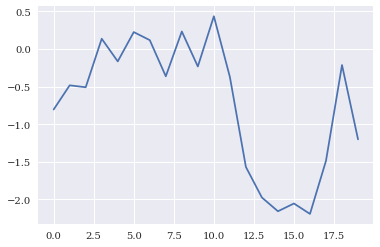

In [6]:
plt.plot(y.cumsum());

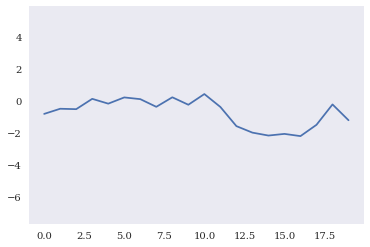

In [7]:
# turn off the grid and customize equalize scaling
plt.plot(y.cumsum())
plt.grid(False)
plt.axis('equal');

### Options for plt.axis() 

| Parameter   | Description |
| ----------- | ----------- |
| Empty      | Returns current axis limits |
| off        | Turns axis lines and labels off |
| equal      | Leads to equal scaling |
| scaled     | Produces equal scaling via dimension changes |
| tight      | Makes all data visible (tightens limits) |
| image      | Makes all data visible (with data limits) |
| [xmin, xmax, ymin, ymax] | sets limits to given (list of) values |

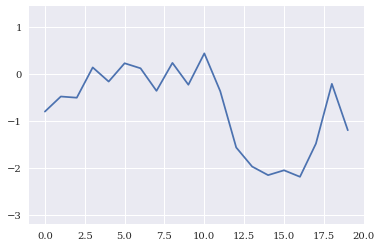

In [8]:
# set custom axis limits
plt.plot(y.cumsum())
plt.xlim(-1, 20)
plt.ylim(np.min(y.cumsum()) - 1,
        np.max(y.cumsum()) + 1);

### Readability
Labeling and describing different pieces of a graph help with presenting data and making plots readible for the intended audience. There are several styling options and things we can do with the matplotlib library to make our graphs more appealing.

Color Options in Matplotlib

| Character   | Color |
| ----------- | ----- |
| b           | Blue |
| g           | Green |
| r           | Red |
| c           | Cyan |
| m           | Magenta |
| y           | Yellow |
| k           | Black |
| w           | White |

Style Options for Matplotlib

| Character   | Symbol |
| ----------- | ------ |
| -           | Solid line |
| --          | Dashed line |
| -.          | Dash=dot line |
| :           | Dotted line |
| .           | Point marker |
| ,           | Pixel marker |
| o           | Circle marker |
| v           | Triangle down marker |
| ^           | Triangle up marker |
| <           | Triangle left marker |
| >           | Triangle right marker |
| 1           | Tri down marker |
| 2           | Tri up marker |
| 3           | Tri left marker |
| 4           | Tri right marker |
| s           | Square marker |
| p           | Pentagon marker |
| *           | Star marker |
| h           | Hexagon1 marker |
| H           | Hexagon2 marker |
| +           | Plus marker |
| x           | X marker |
| D           | Diamond marker |
| d           | Thin diamond marker |
| bar         | Vline marker |
| _           | Hline marker |

Text(0.5, 1.0, 'A Simple Plot')

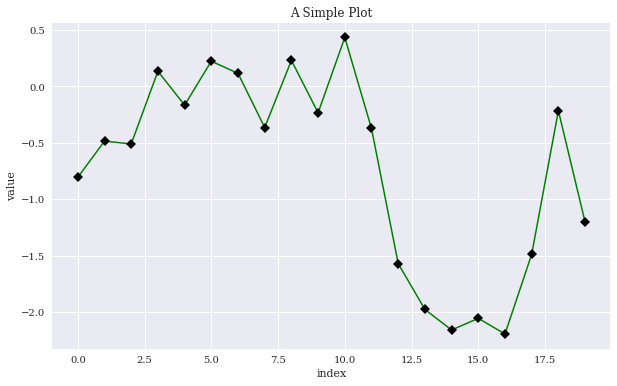

In [9]:
# increase the display size
plt.figure(figsize=(10, 6))
# make the line green with a width of 1.5
plt.plot(y.cumsum(), 'g', lw=1.5)
# plot the data as black diamonds
plt.plot(y.cumsum(), 'kD')
# set label on x-axis
plt.xlabel('index')
# set label on y-axis
plt.ylabel('value')
# give the plot a title
plt.title('A Simple Plot')

## Two-Dimensional Data Sets
We'll give an example of plotting a 2D data set with standard normally distributed pseudo-random numbers. On this array, cumsum() is called to calculate the cumulative sum of the sample data along the first dimension. We can pass 2D arrays plt.plot() and it will automatically interpret the contained data as separate data sets. I'll also add in a legend for this plot, which will show a legend at the "best" location available. Below is a table of all the possible locations for a legend.

| Location   | Description   |
| ---------- | -----------   |
| Default    | Upper right |
| 0  | Best possible |
| 1  | Upper right |
| 2  | Upper left |
| 3  | Lower left |
| 4  | Lower right |
| 5  | Right |
| 6  | Center left |
| 7  | Center right |
| 8  | Lower center |
| 9  | Upper center |
| 10 | Center |

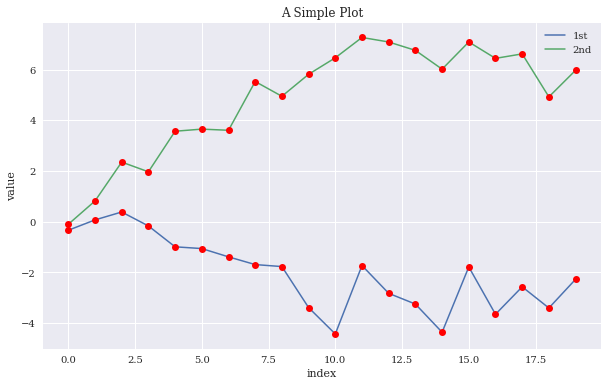

In [10]:
y = np.random.standard_normal((20, 2)).cumsum(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(y[:, 0], lw=1.5, label='1st')
plt.plot(y[:, 1], lw=1.5, label='2nd')
plt.plot(y, 'ro')
plt.legend(loc=0)
plt.xlabel('index')
plt.ylabel('value')
plt.title('A Simple Plot');

### Y-Axis Scaling
Often times data sets will show different scalings and plotting the data on the same y-axis leads to loss of visual information. Here is an example that scales the first of the two data subsets by a factor of 100 and plots the data again. You'll see that the issue here is our second set of data is now 'visually lost', appearing as a straight line. To correct this, there are two different approaches shown below:
- Use of two y-axes (left/right)
- Use of two subplots (upper/lower, left/right)

Text(0.5, 1.0, 'A Simple Plot')

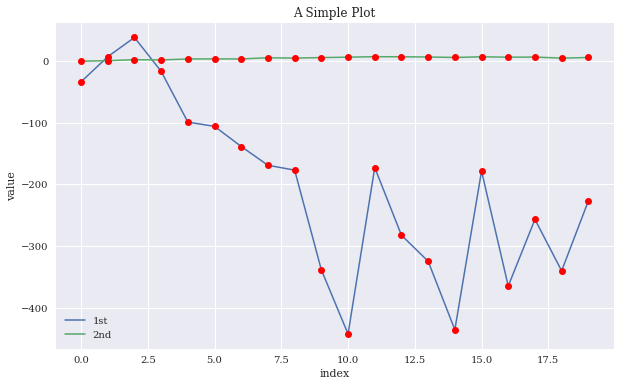

In [11]:
y[:, 0] = y[:, 0] * 100
plt.figure(figsize=(10, 6))
plt.plot(y[:, 0], lw=1.5, label='1st')
plt.plot(y[:, 1], lw=1.5, label='2nd')
plt.plot(y, 'ro')
plt.legend(loc=0)
plt.xlabel('index')
plt.ylabel('value')
plt.title('A Simple Plot')

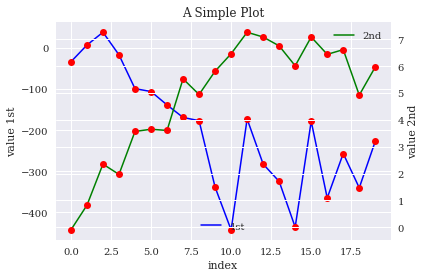

In [12]:
fig, ax1 = plt.subplots()
plt.plot(y[:, 0], 'b', lw=1.5, label='1st')
plt.plot(y[:, 0], 'ro')
plt.legend(loc=8)
plt.xlabel('index')
plt.ylabel('value 1st')
plt.title('A Simple Plot')
ax2 = ax1.twinx()
plt.plot(y[:, 1], 'g', lw=1.5, label='2nd')
plt.plot(y[:, 1], 'ro')
plt.legend(loc=0)
plt.ylabel('value 2nd');

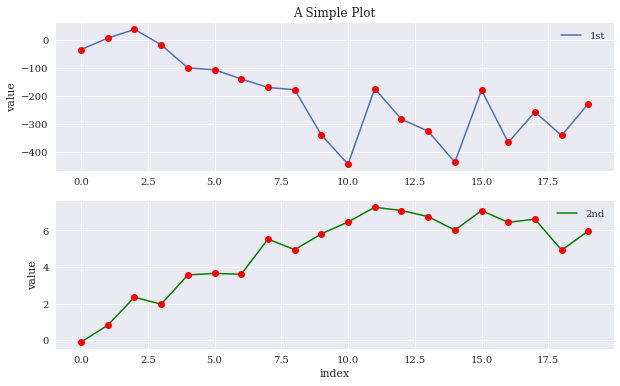

In [13]:
plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(y[:, 0], lw=1.5, label='1st')
plt.plot(y[:, 0], 'ro')
plt.legend(loc=0)
plt.ylabel('value')
plt.title('A Simple Plot')
plt.subplot(212)
plt.plot(y[:, 1], 'g', lw=1.5, label='2nd')
plt.plot(y[:, 1], 'ro')
plt.legend(loc=0)
plt.xlabel('index')
plt.ylabel('value');

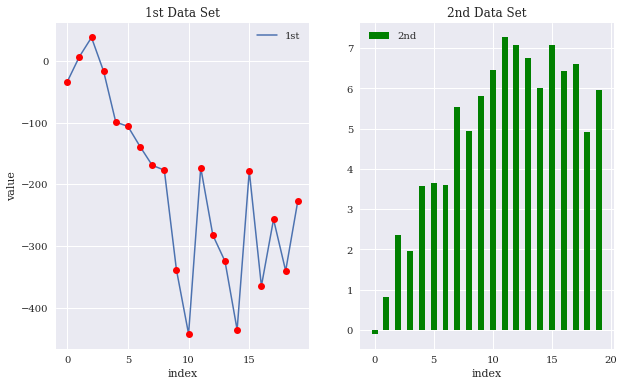

In [14]:
# combine a line plot with a bar chart using sub-plots
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.plot(y[:, 0], lw=1.5, label='1st')
plt.plot(y[:, 0], 'ro')
plt.legend(loc=0)
plt.xlabel('index')
plt.ylabel('value')
plt.title('1st Data Set')
plt.subplot(122)
plt.bar(np.arange(len(y)), y[:, 1], width=0.5, color='g', label='2nd')
plt.legend(loc=0)
plt.xlabel('index')
plt.title('2nd Data Set');

## Other Plot Styles
For two-dimensional plotting, line and point plots are typically the most important when it comes to working with financial data. This is because a lot of the times we will be working with time series data. Although these plots are typically used, we can detail some additional visualizations and approaches to analyzing data. This notebook will serve as a nice reference for pulling out plotting logic when working with real data sets.

First, we'll look at scatter plots. These plot might be considered when evaluating the returns of one financial time series against another one.

In [15]:
y = np.random.standard_normal((1000, 2))

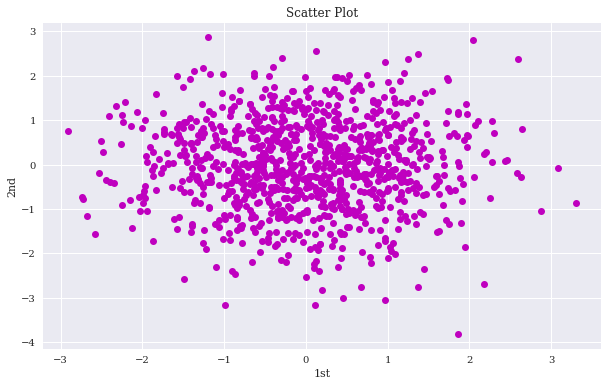

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(y[:, 0], y[:, 1], 'mo')
plt.xlabel('1st')
plt.ylabel('2nd')
plt.title('Scatter Plot');

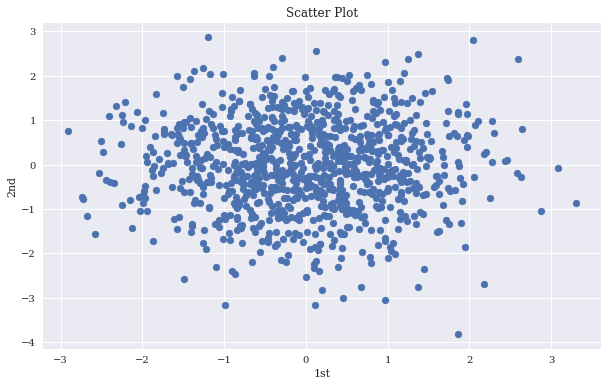

In [17]:
# use the built-in plt.scatter() function
plt.figure(figsize=(10, 6))
plt.scatter(y[:, 0], y[:, 1], marker='o')
plt.xlabel('1st')
plt.ylabel('2nd')
plt.title('Scatter Plot');

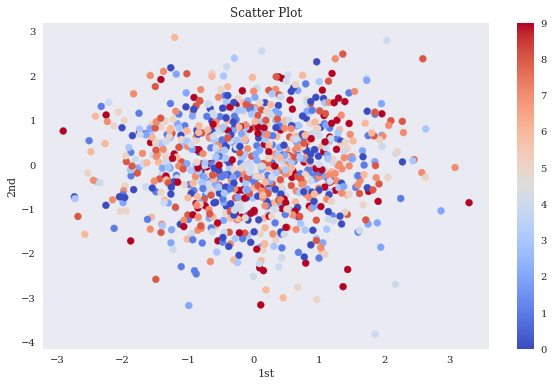

In [18]:
# plt.scatter() allows addition of 3rd diminesion, visualized using color
c = np.random.randint(0, 10, len(y))
plt.rcParams['axes.grid'] = False
plt.figure(figsize=(10, 6))
plt.scatter(y[:, 0], y[:, 1], c=c, cmap='coolwarm', marker='o')
plt.colorbar()
plt.xlabel('1st')
plt.ylabel('2nd')
plt.title('Scatter Plot');

## Histograms
Another common graph used to display statistical analysis is a histogram, which is used to summarize discrete or continuous data that are measured on an interval scale. Below I'll details the parameters available in matplotlib and share some examples.

| Parameter  | Description   |
| ---------- | -----------   |
| x          | a list of values (array) |
| bins       | Number of bins |
| range      | Lower and upper range of bins |
| normed     | Norming such that integral value is 1 |
| weights    | Weights for every value in x |
| cumulative | Every bin contains the counts of the lower bins |
| histtype   | Options (strings): bar, barstacked, step, stepfilled |
| align      | Options (strings): left, mid, right |
| orientation| Options (strings): horizontal, vertical |
| rwidth     | Relative width of bars |
| log        | Log scale              |
| color      | Color per data set (array-like) |
| label      | String or sequence of strings for labels |
| stacked    | Stacks multiple data sets |

<br>

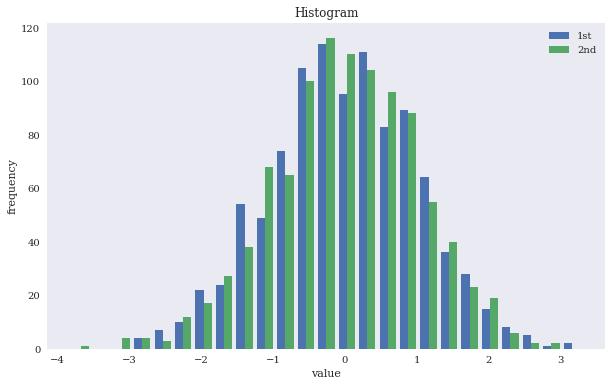

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(y, label=['1st', '2nd'], bins=25)
plt.legend(loc=0)
plt.xlabel('value')
plt.ylabel('frequency')
plt.title('Histogram');

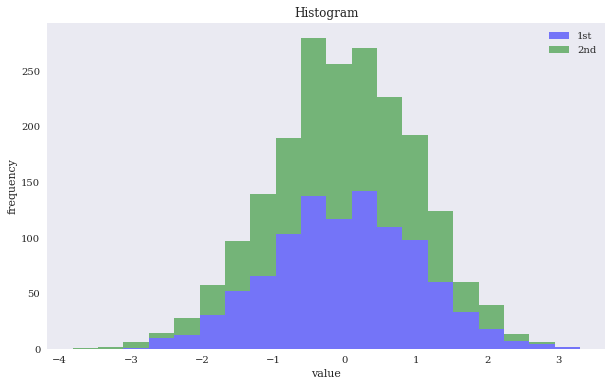

In [20]:
# stacked histogram for comparing 2 data sets
plt.figure(figsize=(10, 6))
plt.hist(y, label=['1st', '2nd'], color=['b', 'g'], stacked=True, bins=20, alpha=0.5)
plt.legend(loc=0)
plt.xlabel('value')
plt.ylabel('frequency')
plt.title('Histogram');

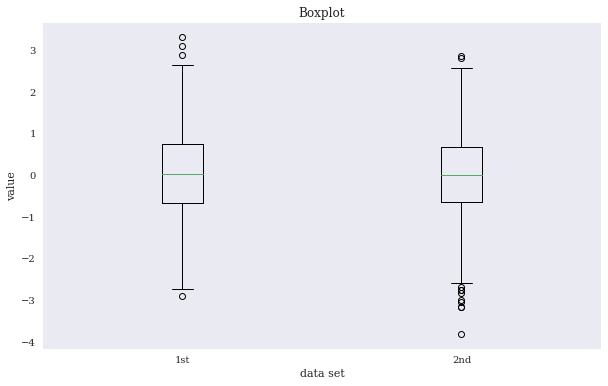

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.boxplot(y)
plt.setp(ax, xticklabels=['1st', '2nd'])
plt.xlabel('data set')
plt.ylabel('value')
plt.title('Boxplot');

## Area Below Function

Plots out a function and highlights graphically the area below the function from a lower and to an upper limit -- the integral value of the function between the lower and upper limits. The integral (value) to be illustrated is $\begin{align}\int_{a}^{b} f(x) \,dx\end{align}$ with $\begin{align}f(x) = \frac{1}{2} * e^x + 1\end{align}$, $\begin{align}a = \frac{1}{2}\end{align}$, and $\begin{align}b = \frac{3}{2}\end{align}$

<br>

In [22]:
# define the function we're measuring
def func(x):
    return 0.5 * np.exp(x) + 1

In [23]:
# set the variables
a, b = 0.5, 1.5
x = np.linspace(0, 2)
y = func(x)
Ix = np.linspace(a, b)
Iy = func(Ix)
verts = [(a, 0)] + list(zip(Ix, Iy)) + [(b, 0)]

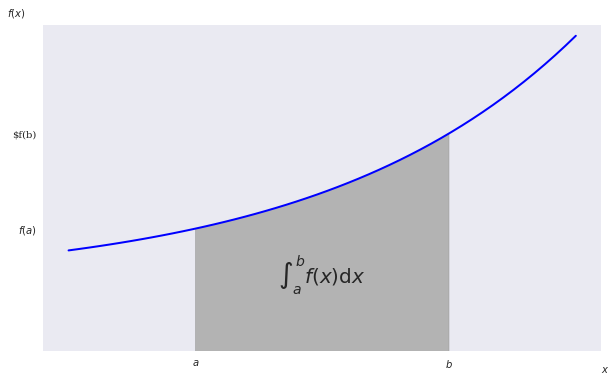

In [24]:
from matplotlib.patches import Polygon
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(x, y, 'b', linewidth=2)
plt.ylim(bottom=0)
poly = Polygon(verts, facecolor='0.7', edgecolor='0.5')
ax.add_patch(poly)
plt.text(0.5 * (a + b), 1, r'$\int_a^b f(x)\mathrm{d}x$', horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')
ax.set_xticks((a, b))
ax.set_xticklabels(('$a$', '$b$'))
ax.set_yticks([func(a), func(b)])
ax.set_yticklabels(('$f(a)$', '$f(b)'));

## Static 3D Plotting

This is not so relavent for finance, but 3D plotting is good for calculas and other derivatives engineering. An application that is applicable to finance is volatility surfaces. These plots can show implied volatilities simultaneously for a number of times-to-maturity and strikes of the traded options used.

| Parameter  | Description   |
| ---------- | -----------   |
| X, Y, Z    | Data values as 2D arrays |
| rstride    | Array row stride (step size) |
| cstride    | Array column stride (step size) |
| color      | Color of surface patches |
| cmap       | Color map for the surface patches |
| facecolors | Face colors for individual patches |
| norm       | Instance of Normalize to map values to colors |
| vmin       | Minimum value to map |
| vmax       | Maximum value to map |
| shade      | Whether to shade the face colors |

<br>

In [25]:
strike = np.linspace(50, 150, 24)

In [26]:
ttm = np.linspace(0.5, 2.5, 24)

In [27]:
strike, ttm = np.meshgrid(strike, ttm)

In [28]:
strike[:2].round(1)

array([[ 50. ,  54.3,  58.7,  63. ,  67.4,  71.7,  76.1,  80.4,  84.8,
         89.1,  93.5,  97.8, 102.2, 106.5, 110.9, 115.2, 119.6, 123.9,
        128.3, 132.6, 137. , 141.3, 145.7, 150. ],
       [ 50. ,  54.3,  58.7,  63. ,  67.4,  71.7,  76.1,  80.4,  84.8,
         89.1,  93.5,  97.8, 102.2, 106.5, 110.9, 115.2, 119.6, 123.9,
        128.3, 132.6, 137. , 141.3, 145.7, 150. ]])

In [29]:
iv = (strike - 100) ** 2 / (100 * strike) / ttm

In [30]:
iv[:5, :3]

array([[1.        , 0.76695652, 0.58132045],
       [0.85185185, 0.65333333, 0.4951989 ],
       [0.74193548, 0.56903226, 0.43130227],
       [0.65714286, 0.504     , 0.38201058],
       [0.58974359, 0.45230769, 0.34283001]])

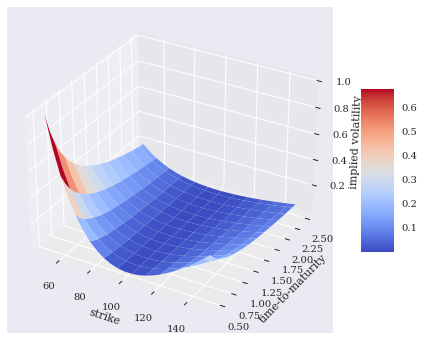

In [31]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(strike, ttm, iv, rstride=2, cstride=2, cmap=plt.cm.coolwarm, linewidth=0.5, antialiased=True)
ax.set_xlabel('strike')
ax.set_ylabel('time-to-maturity')
ax.set_zlabel('implied volatility')
fig.colorbar(surf, shrink=0.5, aspect=5);

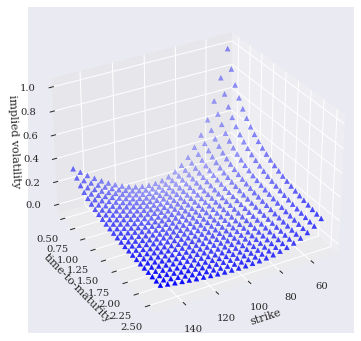

In [32]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(30, 60)
ax.scatter(strike, ttm, iv, zdir='z', s=25, c='b', marker='^')
ax.set_xlabel('strike')
ax.set_ylabel('time-to-maturity')
ax.set_zlabel('implied volatility');

## Basic Plots
Looking at interactive plotting from within the context of a Jupyter Notebook. The library we're using, plotly, also has an option to get the plots rendered on their remote servers. Notebook mode is turned on in this example for speed, especially when we start to look at larger data sets. Streaming plots would require using the server connection.

In [33]:
import pandas as pd
import cufflinks as cf
import plotly.offline as plyo

In [34]:
plyo.init_notebook_mode(connected=True)

In [35]:
a = np.random.standard_normal((250, 5)).cumsum(axis=0)
index = pd.date_range('2019-1-1', freq='B', periods=len(a))
df = pd.DataFrame(100 + 5 * a, columns=list('abcde'), index=index)
df.head()

,a,b,c,d,e
2019-01-01,109.037535,98.693865,104.474094,96.878857,100.621936
2019-01-02,107.598242,97.005738,106.789189,97.966552,100.175313
2019-01-03,101.639668,100.332253,103.183500,99.747869,107.902901
2019-01-04,98.500363,101.208283,100.966242,94.023898,104.387256
2019-01-07,93.941632,103.319168,105.674012,95.891062,86.547934


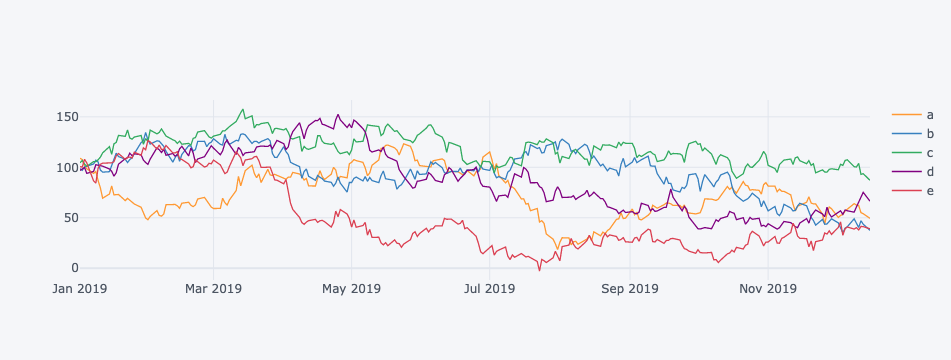

In [36]:
plyo.iplot(
    df.iplot(asFigure=True), 
    image='png', 
    filename='ply_01'
)

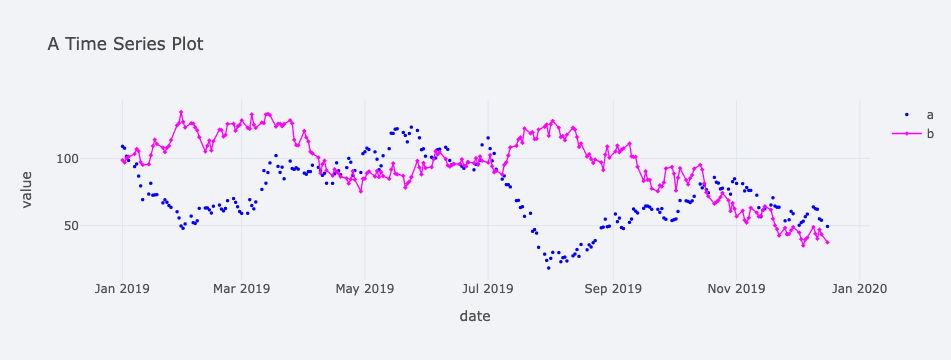

In [37]:
plyo.iplot(
    df[['a', 'b']].iplot(asFigure=True, theme='polar', 
                         title='A Time Series Plot', 
                         xTitle='date', 
                         yTitle='value', 
                         mode={'a': 'markers', 'b': 'lines+markers'}, 
                         symbol={'a': 'circle', 'b': 'diamond'}, 
                         size=3.5, 
                         colors={'a': 'blue', 'b': 'magenta'},
                        ), 
    image='png', 
    filename='ply_02'
)

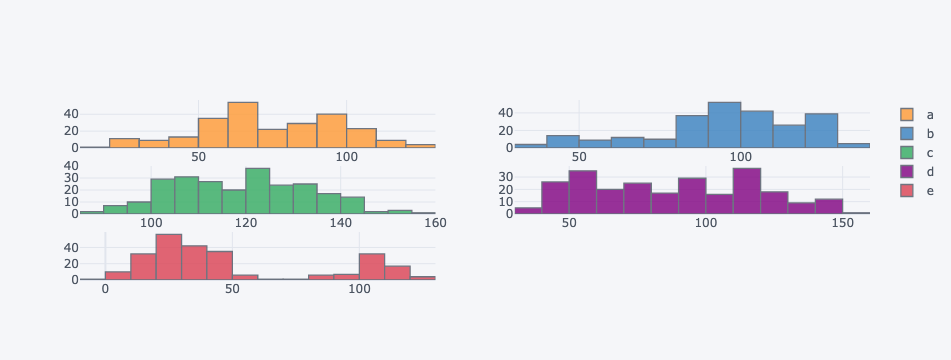

In [38]:
plyo.iplot(
    df.iplot(
        kind='hist', 
        subplots=True, 
        bins=15, 
        asFigure=True
    ),
    image='png',
    filename='ply_03'
)

## Financial Plots
Cufflinks' library provides useful functions for ploting financial data, typical charting elements such as Relative Strength Index (RSI) are able to be used out of the box. We can work through an example time-series data set to show off some of these capabilities.

[free yahoo](https://stackoverflow.com/questions/33978901/python-pandas-api-for-yahoo-finance-how-to-get-the-bid-ask-prices-and-other-fi)

[pandas can only stay awake for so long](https://buildmedia.readthedocs.org/media/pdf/pandas-datareader/stable/pandas-datareader.pdf)

In [39]:
import pandas as pd
import pandas_datareader as io

**Date Controller**

In [40]:
start_date = '2018-07-15'
end_date = '2022-03-30'

**Conversion Rates**

In [41]:
eurusd = io.data.DataReader('EURUSD%3DX', data_source='yahoo', start=start_date, end=end_date)
eurusd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 968 entries, 2018-07-15 to 2022-03-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       968 non-null    float64
 1   Low        968 non-null    float64
 2   Open       968 non-null    float64
 3   Close      968 non-null    float64
 4   Volume     968 non-null    float64
 5   Adj Close  968 non-null    float64
dtypes: float64(6)
memory usage: 52.9 KB


In [42]:
quotes = eurusd[['Open', 'High', 'Low', 'Close']]
quotes = quotes.iloc[-60:]
quotes.tail()

,Open,High,Low,Close
Date,,,,
2022-03-25,1.100897,1.103875,1.098298,1.100958
2022-03-27,1.098189,1.099674,1.094535,1.098189
2022-03-28,1.099384,1.113635,1.097045,1.099384
2022-03-29,1.109152,1.117000,1.108906,1.109152
2022-03-30,1.116184,1.118306,1.107400,1.116184


In [43]:
qf = cf.QuantFig(
    quotes,
    title='EUR/USD Exchange Rate',
    legend='top',
    name='EUR/USD'
)

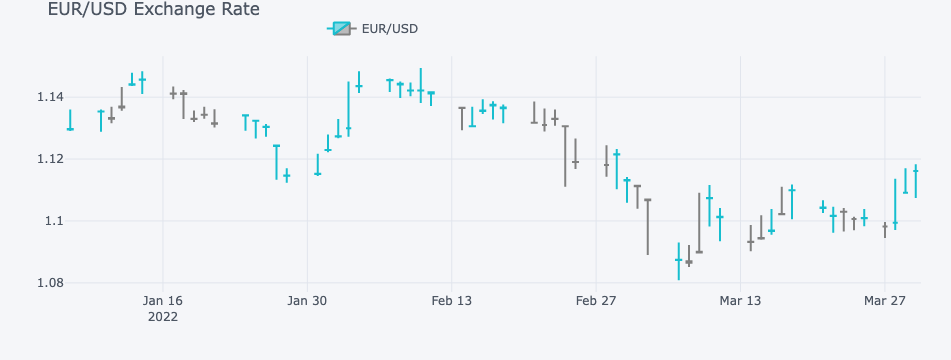

In [44]:
plyo.iplot(
    qf.iplot(asFigure=True),
    image='png',
    filename='qf_01'
)

**Additional Financial Elements**

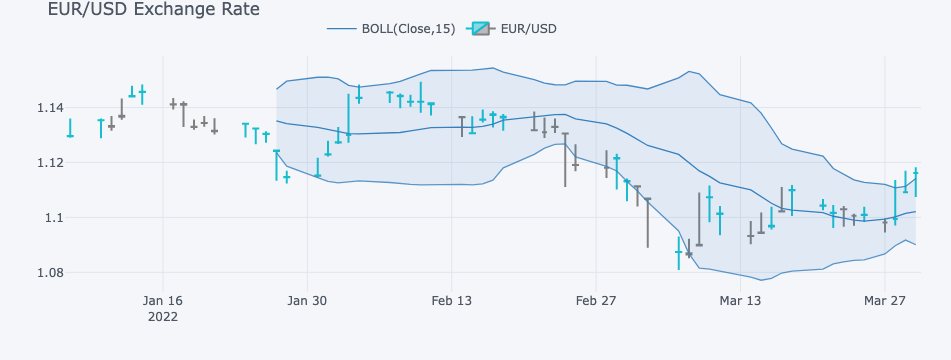

In [45]:
qf.add_bollinger_bands(periods=15, boll_std=2)
plyo.iplot(
    qf.iplot(asFigure=True), 
    image='png', 
    filename='qf_02'
)

**Subplot RSI**

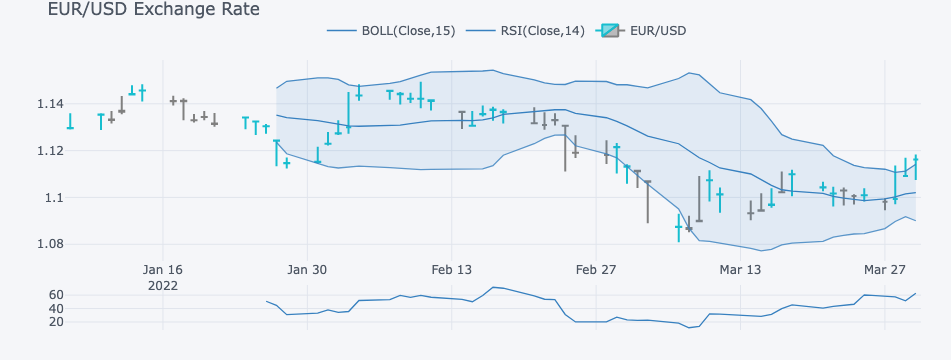

In [46]:
qf.add_rsi(periods=14, showbands=False)
plyo.iplot(
    qf.iplot(asFigure=True),
    image='png',
    filename='qf_03'
)

## Conclusions
Matplotlib is the gold standard for data visualization in python. It's integrations with dataframes using libraries like pandas make it easy to quickly automate data intake, cleaning and presentation as an end-to-end automated process. This allows analysts to interpret and react to data faster. Matplotlib's capabilities are dense and it is complicated to try and navigate all of the different API options available when working in python, especially with the expanding use of open-source software. Creating examples that can be referenced and reused is important to cut down on knowledge transfer with collaborators who may be using different toolkits.

**Additional Resources**

- [matplot gallery](https://matplotlib.org/stable/index.html)
- [plotly](https://plotly.com/)
- [cufflinks](https://github.com/santosjorge/cufflinks)